In [ ]:
SEED = 42
import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
from pathlib import Path
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

# BUG-008: Load CGAN synthetic data with existence guard
SYNTH_DIR = Path("../data/synthetic/GAN")
synth_X_path = SYNTH_DIR / "synth_X.npy"
synth_labels_path = SYNTH_DIR / "synth_labels.npy"

if not synth_X_path.exists() or not synth_labels_path.exists():
    raise FileNotFoundError(
        "CGAN synthetic data not found. "
        "Please run Phase 6 (06_synthetic_fault_generation.ipynb) first.\n"
        f"  Missing: {synth_X_path}\n"
        f"  Missing: {synth_labels_path}"
    )

X_synth = np.load(synth_X_path)
y_synth = np.load(synth_labels_path)

import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp
import json
import warnings
warnings.filterwarnings("ignore")

DATA_DIR  = Path("../data/processed/FD001")

X_real  = np.load(DATA_DIR  / "X_train.npy")
labels  = np.load(DATA_DIR  / "labels_train.npy")

CLASS_NAMES  = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]

print(f"Real  : {X_real.shape}  labels: {labels.shape}")


In [15]:
# Identify dead sensors in synthetic output (std ~ 0 across all samples)
synth_std = X_synth.std(axis=(0, 1))   # (num_features,)
dead_mask = synth_std < 0.01
dead_sensors = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if dead_mask[i]]

print("Sensor std in synthetic data:")
for i, (col, std) in enumerate(zip(FEATURE_COLS, synth_std)):
    status = "DEAD" if dead_mask[i] else "ok"
    print(f"  {col:<6}: std={std:.4f}  {status}")

print(f"\nDead sensors identified: {dead_sensors}")

# mask dead sensors in BOTH real and synthetic so metrics
# measure similarity on active features only
dead_indices = [i for i in range(len(FEATURE_COLS)) if dead_mask[i]]

X_real_m  = X_real.copy()
X_synth_m = X_synth.copy()
for idx in dead_indices:
    X_real_m[:, :, idx]  = 0.0
    X_synth_m[:, :, idx] = 0.0

print(f"\nMasked {len(dead_indices)} dead sensor(s) in both real and synthetic.")
print("Proceeding with masked arrays for all metrics.")


Sensor std in synthetic data:
  op1   : std=0.1749  ok
  op2   : std=0.2718  ok
  s2    : std=0.1917  ok
  s3    : std=0.1181  ok
  s4    : std=0.1848  ok
  s7    : std=0.1691  ok
  s8    : std=0.2098  ok
  s9    : std=0.2204  ok
  s11   : std=0.1884  ok
  s12   : std=0.1448  ok
  s13   : std=0.2068  ok
  s14   : std=0.2103  ok
  s15   : std=0.1884  ok
  s17   : std=0.2059  ok
  s20   : std=0.1911  ok
  s21   : std=0.1755  ok

Dead sensors identified: []

Masked 0 dead sensor(s) in both real and synthetic.
Proceeding with masked arrays for all metrics.


In [16]:
def compute_mmd(X, Y, sigma=1.0):
    def rbf(A, B):
        A = torch.tensor(A, dtype=torch.float32)
        B = torch.tensor(B, dtype=torch.float32)
        AA = (A * A).sum(1, keepdim=True)
        BB = (B * B).sum(1, keepdim=True)
        AB = A @ B.T
        return torch.exp(-(AA + BB.T - 2*AB) / (2 * sigma**2))
    return (rbf(X,X).mean() + rbf(Y,Y).mean() - 2*rbf(X,Y).mean()).item()

N_SAMPLE = 500
mmd_results = []

for c in range(4):
    real_c  = X_real_m[labels   == c]
    synth_c = X_synth_m[y_synth == c]

    if len(synth_c) == 0:
        mmd_results.append({"class": CLASS_NAMES[c], "mmd": None,
                             "n_real": len(real_c), "n_synth": 0})
        continue

    r_idx = np.random.choice(len(real_c),  min(N_SAMPLE, len(real_c)),  replace=False)
    s_idx = np.random.choice(len(synth_c), min(N_SAMPLE, len(synth_c)), replace=False)
    R = real_c[r_idx].reshape(len(r_idx), -1)
    S = synth_c[s_idx].reshape(len(s_idx), -1)

    mmd_results.append({"class": CLASS_NAMES[c],
                         "mmd"    : round(compute_mmd(R, S), 6),
                         "n_real" : len(real_c),
                         "n_synth": len(synth_c)})

mmd_df = pd.DataFrame(mmd_results)
print("MMD scores (lower = more similar to real):")
print(mmd_df.to_string(index=False))
print("\nTarget: < 0.1 acceptable  |  < 0.05 good")


MMD scores (lower = more similar to real):
      class      mmd  n_real  n_synth
 C0 healthy      NaN    7633        0
   C1 early 0.006071    4998     2635
C2 advanced 0.010472    4000     3633
C3 imminent 0.012677    1100     6533

Target: < 0.1 acceptable  |  < 0.05 good


In [17]:
ks_results = []
active_features = [FEATURE_COLS[i] for i in range(len(FEATURE_COLS)) if not dead_mask[i]]

for c in range(4):
    real_c  = X_real_m[labels   == c]
    synth_c = X_synth_m[y_synth == c]
    if len(synth_c) == 0:
        continue
    for f_idx, feat in enumerate(FEATURE_COLS):
        if dead_mask[f_idx]:
            continue   # skip dead sensors
        stat, pval = ks_2samp(
            real_c[:, :, f_idx].flatten(),
            synth_c[:, :, f_idx].flatten()
        )
        ks_results.append({
            "class"  : f"C{c}",
            "sensor" : feat,
            "ks_stat": round(stat, 4),
            "p_value": round(pval, 4),
            "pass"   : pval > 0.05,
        })

ks_df     = pd.DataFrame(ks_results)
pass_rate = ks_df["pass"].mean() * 100
print(f"KS test overall pass rate (active sensors only): {pass_rate:.1f}%")
print(ks_df.groupby("class")["pass"].mean().apply(lambda x: f"{x*100:.1f}%"))
print(f"\nActive sensors tested: {active_features}")


KS test overall pass rate (active sensors only): 0.0%
class
C1    0.0%
C2    0.0%
C3    0.0%
Name: pass, dtype: object

Active sensors tested: ['op1', 'op2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [18]:
X_r = X_real_m.reshape(len(X_real_m), -1)
X_s = X_synth_m.reshape(len(X_synth_m), -1)

min_n = min(len(X_r), len(X_s))
idx_r = np.random.choice(len(X_r), min_n, replace=False)
idx_s = np.random.choice(len(X_s), min_n, replace=False)

X_disc    = np.concatenate([X_r[idx_r], X_s[idx_s]], axis=0)
y_disc    = np.array([0]*min_n + [1]*min_n)
X_disc_sc = StandardScaler().fit_transform(X_disc)

clf    = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores = cross_val_score(clf, X_disc_sc, y_disc, cv=5, scoring="accuracy")

disc_score = scores.mean()
print(f"Discriminative score : {disc_score:.3f} +/- {scores.std():.3f}")
print(f"Target               : ~0.50 ideal  |  < 0.75 acceptable")
if disc_score < 0.60:
    print("Verdict: GOOD")
elif disc_score < 0.75:
    print("Verdict: ACCEPTABLE")
else:
    print("Verdict: POOR")


Discriminative score : 0.989 +/- 0.001
Target               : ~0.50 ideal  |  < 0.75 acceptable
Verdict: POOR


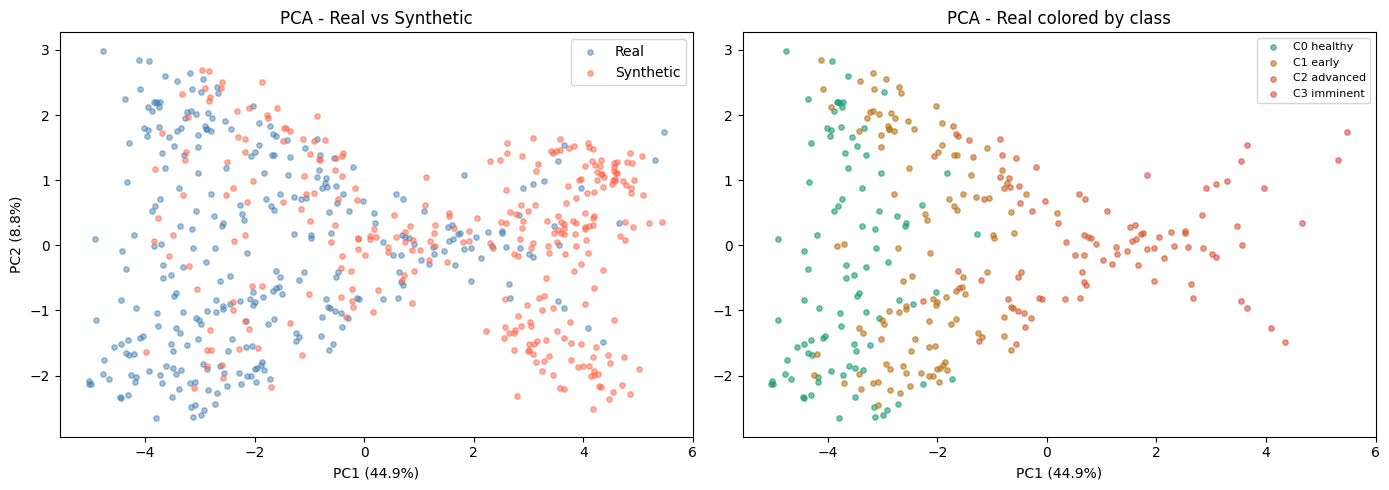

In [19]:
N_VIZ    = 300
X_r_flat = X_real_m.reshape(len(X_real_m), -1)
X_s_flat = X_synth_m.reshape(len(X_synth_m), -1)

r_idx = np.random.choice(len(X_r_flat), N_VIZ, replace=False)
s_idx = np.random.choice(len(X_s_flat), N_VIZ, replace=False)

X_combined = np.concatenate([X_r_flat[r_idx], X_s_flat[s_idx]], axis=0)
pca        = PCA(n_components=2)
X_pca      = pca.fit_transform(X_combined)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:N_VIZ, 0], X_pca[:N_VIZ, 1],
                c="steelblue", alpha=0.5, s=15, label="Real")
axes[0].scatter(X_pca[N_VIZ:, 0], X_pca[N_VIZ:, 1],
                c="tomato",    alpha=0.5, s=15, label="Synthetic")
axes[0].set_title("PCA - Real vs Synthetic")
axes[0].legend()
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

colors = ["#1D9E75","#BA7517","#D85A30","#E24B4A"]
for c in range(4):
    mask = labels[r_idx] == c
    axes[1].scatter(X_pca[:N_VIZ][mask, 0], X_pca[:N_VIZ][mask, 1],
                    c=colors[c], alpha=0.6, s=15, label=CLASS_NAMES[c])
axes[1].set_title("PCA - Real colored by class")
axes[1].legend(fontsize=8)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")

plt.tight_layout()
plt.savefig("../reports/figures/pca_real_vs_synth.png", dpi=150, bbox_inches="tight")
plt.show()


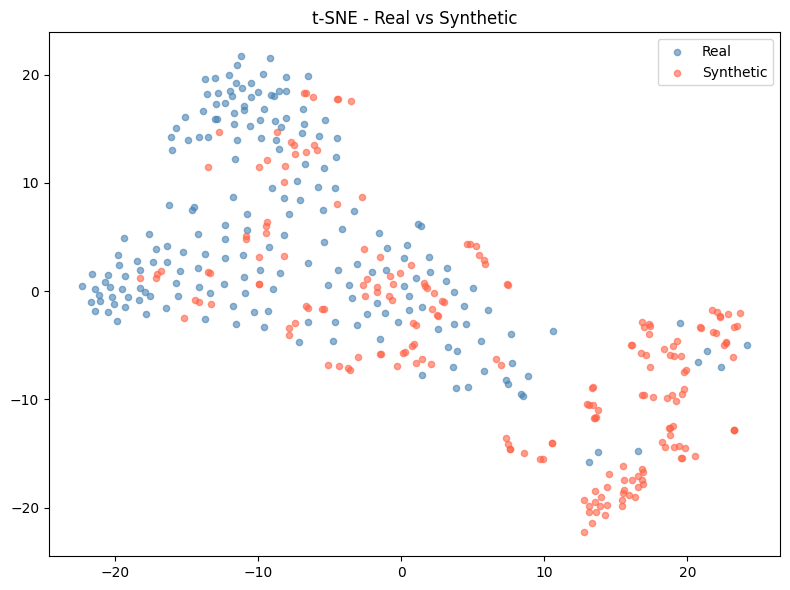

Good: clusters overlap  |  Poor: two separate blobs


In [20]:
N_TSNE = 200
r_idx  = np.random.choice(len(X_r_flat), N_TSNE, replace=False)
s_idx  = np.random.choice(len(X_s_flat), N_TSNE, replace=False)

X_tsne_in = np.concatenate([X_r_flat[r_idx], X_s_flat[s_idx]], axis=0)
X_tsne    = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne[:N_TSNE, 0], X_tsne[:N_TSNE, 1],
           c="steelblue", alpha=0.6, s=20, label="Real")
ax.scatter(X_tsne[N_TSNE:, 0], X_tsne[N_TSNE:, 1],
           c="tomato",    alpha=0.6, s=20, label="Synthetic")
ax.set_title("t-SNE - Real vs Synthetic")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/tsne_real_vs_synth.png", dpi=150, bbox_inches="tight")
plt.show()

print("Good: clusters overlap  |  Poor: two separate blobs")


In [21]:
MONOTONE_INCREASING = ["s4"]
MONOTONE_DECREASING = ["s3", "s7", "s11"]
X_mean_synth = X_synth.mean(axis=1)

results = []
for sensor in MONOTONE_INCREASING + MONOTONE_DECREASING:
    if sensor not in FEATURE_COLS:
        continue
    idx       = FEATURE_COLS.index(sensor)
    direction = "increase" if sensor in MONOTONE_INCREASING else "decrease"
    class_means = []
    for c in range(4):
        mask = y_synth == c
        class_means.append(X_mean_synth[mask, idx].mean() if mask.sum() > 0 else np.nan)

    valid = [m for m in class_means if not np.isnan(m)]
    if direction == "increase":
        holds = all(valid[i] <= valid[i+1] for i in range(len(valid)-1))
    else:
        holds = all(valid[i] >= valid[i+1] for i in range(len(valid)-1))

    results.append({"sensor": sensor, "direction": direction,
                    "C0": round(class_means[0], 4) if not np.isnan(class_means[0]) else "N/A",
                    "C1": round(class_means[1], 4),
                    "C2": round(class_means[2], 4),
                    "C3": round(class_means[3], 4),
                    "monotone_holds": holds})

mono_df = pd.DataFrame(results)
print("Physics monotonicity on synthetic data:")
print(mono_df.to_string(index=False))


Physics monotonicity on synthetic data:
sensor direction  C0     C1     C2     C3  monotone_holds
    s4  increase N/A 0.3454 0.5136 0.6802            True
    s3  decrease N/A 0.4007 0.4671 0.5569           False
    s7  decrease N/A 0.6672 0.4985 0.3312            True
   s11  decrease N/A 0.3309 0.4845 0.6898           False


In [22]:
print("=" * 55)
print("        PHASE 7 VALIDATION SUMMARY")
print("=" * 55)

print(f"\nDead sensors masked : {dead_sensors}")

print("\n1. MMD Scores (masked):")
for _, row in mmd_df.iterrows():
    if row["mmd"] is None:
        print(f"   {row['class']:<20}: skipped (no synth)")
    else:
        q = "GOOD" if row["mmd"] < 0.05 else "ACCEPTABLE" if row["mmd"] < 0.1 else "POOR"
        print(f"   {row['class']:<20}: {row['mmd']:.5f}  ({q})")

print(f"\n2. KS pass rate     : {pass_rate:.1f}%  (active sensors only)")

disc_verdict = "GOOD" if disc_score < 0.60 else "ACCEPTABLE" if disc_score < 0.75 else "POOR"
print(f"3. Disc score       : {disc_score:.3f}  ({disc_verdict})")

mono_pass = mono_df['monotone_holds'].sum()
print(f"4. Monotonicity     : {mono_pass}/4 pass")

go = disc_score < 0.75 and pass_rate > 20 and mono_pass >= 1
print(f"\n5. Proceed to Phase 8: {'YES' if go else 'NO - review metrics above'}")
print("=" * 55)

with open(DATA_DIR / "validation_summary.json", "w") as f:
    json.dump({
        "dead_sensors"     : dead_sensors,
        "ks_pass_rate_pct" : round(pass_rate, 2),
        "disc_score"       : round(float(disc_score), 4),
        "disc_verdict"     : disc_verdict,
        "monotone_pass"    : int(mono_pass),
        "proceed_phase8"   : bool(go),
    }, f, indent=2)
print("Saved validation_summary.json")


        PHASE 7 VALIDATION SUMMARY

Dead sensors masked : []

1. MMD Scores (masked):
   C0 healthy          : nan  (POOR)
   C1 early            : 0.00607  (GOOD)
   C2 advanced         : 0.01047  (GOOD)
   C3 imminent         : 0.01268  (GOOD)

2. KS pass rate     : 0.0%  (active sensors only)
3. Disc score       : 0.989  (POOR)
4. Monotonicity     : 2/4 pass

5. Proceed to Phase 8: NO - review metrics above
Saved validation_summary.json
